# **Load Data and Zero Crossing Rate**

In [1]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import shutil
import os

In [2]:
# Import Libraries
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Load sample audio and Zero Crossing Rate
signal, sr = librosa.load('./data/train/healthy/a0007.wav')
signal_un, sr_un = librosa.load('./data/train/unhealthy/a0008.wav')



In [4]:
# Function to compute ZCR per short frame (e.g., 20–30 ms) to capture temporal variations:

def zcr(rate, data):
  frame_size = int(0.02 * rate)  # 20 ms frame
  num_frames = len(data) // frame_size

  zcrs = []

  for i in range(num_frames):
      start = i * frame_size
      end = start + frame_size
      frame = data[start:end]
      signs = np.sign(frame)
      crossings = np.where(np.diff(signs))[0]
      zcr_frame = len(crossings) / frame_size
      zcrs.append(zcr_frame)

  # Average ZCR across all frames
  avg_zcr = np.mean(zcrs)
  print("Average Zero-Crossing Rate:", avg_zcr)

Average Zero-Crossing Rate: 0.0030865963884151525
Average Zero-Crossing Rate: 0.0034659673925436095


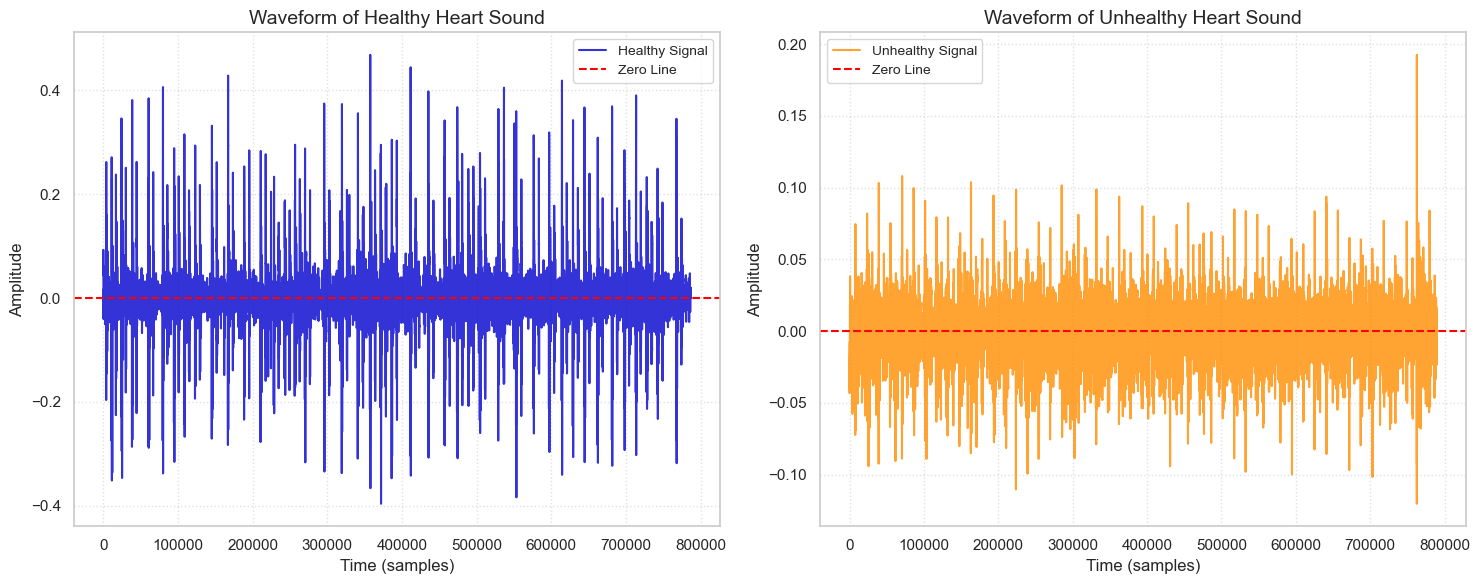

In [5]:
# Compute the sign of the samples
healty_signal = zcr(sr, signal)
unhealthy_signal = zcr(sr_un, signal_un)

import seaborn as sns

# Set seaborn style for better aesthetics
sns.set_theme(style="whitegrid")

plt.figure(figsize=(15, 6))

# Plot for Healthy Signal
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(signal, label='Healthy Signal', color='mediumblue', alpha=0.8)
plt.axhline(0, color='red', linestyle='--', label='Zero Line', linewidth=1.5)
plt.title('Waveform of Healthy Heart Sound', fontsize=14)
plt.xlabel('Time (samples)', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)

# Plot for Unhealthy Signal
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(signal_un, label='Unhealthy Signal', color='darkorange', alpha=0.8)
plt.axhline(0, color='red', linestyle='--', label='Zero Line', linewidth=1.5)
plt.title('Waveform of Unhealthy Heart Sound', fontsize=14)
plt.xlabel('Time (samples)', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

# **Preprocessing**

In [6]:
# Bandpass filtering

def bandpass_filter(data, lowcut, highcut, fs):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(4, [low, high], btype='band')
    filtered = filtfilt(b, a, data)

    return filtered

filtered_signal = bandpass_filter(signal, 20, 400, sr)

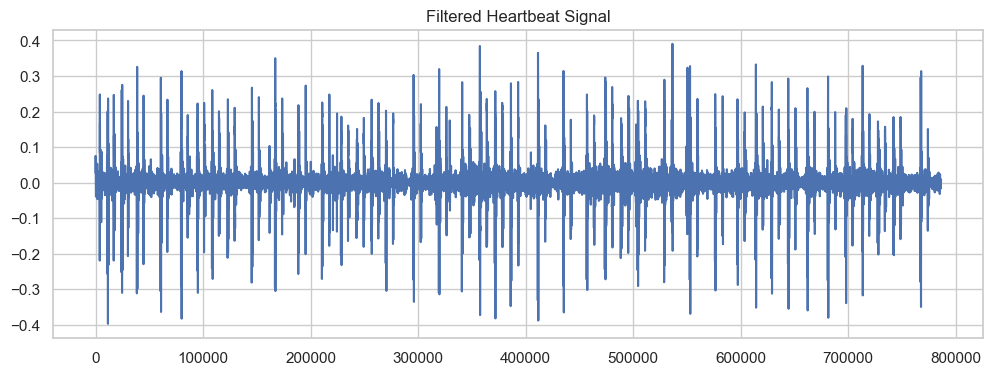

In [7]:
plt.figure(figsize=(12,4))
plt.plot(filtered_signal)
plt.title("Filtered Heartbeat Signal")
plt.show()

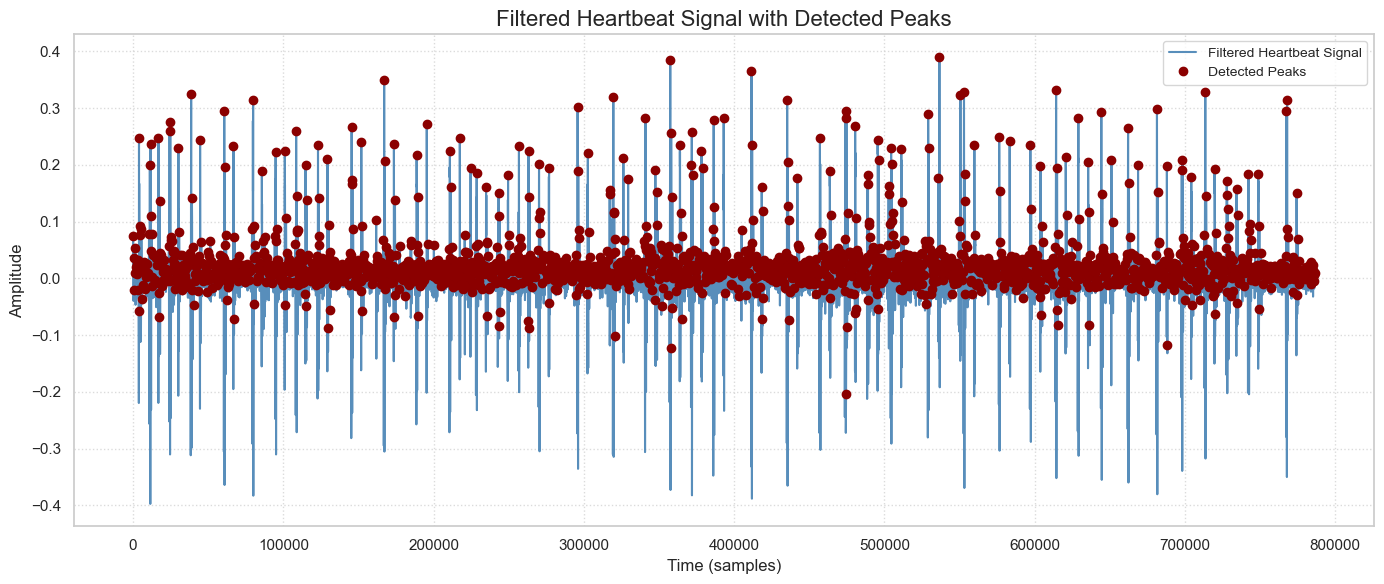

In [8]:
# Detect the heartbeat(high frequncies)
peaks, _ = find_peaks(filtered_signal, distance=200)

import seaborn as sns
sns.set_theme(style="whitegrid")

plt.figure(figsize=(14, 6))
plt.plot(filtered_signal, label='Filtered Heartbeat Signal', color='steelblue', alpha=0.9)
plt.plot(peaks, filtered_signal[peaks], "o", color='darkred', markersize=6, label='Detected Peaks')
plt.title('Filtered Heartbeat Signal with Detected Peaks', fontsize=16)
plt.xlabel('Time (samples)', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

In [9]:
beats = []

window = int(0.3 * sr)

for p in peaks:
    start = max(p - window//2, 0)
    end = min(p + window//2, len(filtered_signal))
    beats.append(filtered_signal[start:end])

In [10]:
beat = beats[0]

mfcc = librosa.feature.mfcc(y=beat, sr=sr, n_mfcc=13)
zcr = librosa.feature.zero_crossing_rate(beat)
centroid = librosa.feature.spectral_centroid(y=beat, sr=sr)

features = np.concatenate([
    np.mean(mfcc, axis=1),
    [np.mean(zcr)],
    [np.mean(centroid)]
])

print('mfcc', mfcc[:1])
print('zcr', zcr[:5])
print('centroid', centroid.shape)


mfcc [[-384.22259321 -450.15855971 -716.32075916 -712.68526773 -704.77263808
  -589.66328086 -431.72595894]]
zcr [[0.00146484 0.00292969 0.00390625 0.00341797 0.00439453 0.00341797
  0.00244141]]
centroid (1, 7)


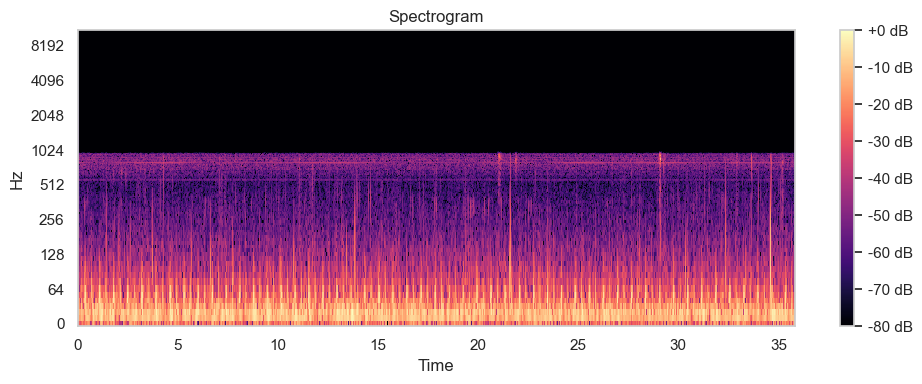

In [11]:
# Spectogram of the sample audio

# Compute spectrogram
S = librosa.stft(signal_un)
S_db = librosa.amplitude_to_db(abs(S), ref=np.max)

# Plot spectrogram
plt.figure(figsize=(10,4))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title("Spectrogram")
plt.tight_layout()
plt.show()

# **Load the files**

In [12]:
#
train_path = "./data/train"
val_path = "./data/val"

In [13]:
# Function to Load Dataset
# Change these paths to your Colab upload folder

def load_audio_files(base_path):
    audio_list = []
    labels = []
    for label_name, label_value in [("healthy", 0), ("unhealthy", 1)]:
        folder = os.path.join(base_path, label_name)
        for fname in os.listdir(folder):
            path = os.path.join(folder, fname)
            try:
                signal, sr = librosa.load(path, sr=None)
                audio_list.append((signal, sr))
                labels.append(label_value)
            except:
                print(f"Could not load {path}")
    return audio_list, np.array(labels)

train_audio, y_train = load_audio_files(train_path)
val_audio, y_val = load_audio_files(val_path)

print(f"Train samples: {len(train_audio)}, Validation samples: {len(val_audio)}")

Train samples: 3240, Validation samples: 301


# **Implementation with Random Forest**

In [14]:
# Detect Peaks and Segment Heartbeat

def segment_beats(signal, sr, lowcut=20, highcut=400, window_sec=0.3):
    # Band-pass filter
    filtered = bandpass_filter(signal, lowcut, highcut, sr)

    # Detect peaks
    peaks, _ = find_peaks(filtered, distance=int(0.3*sr))

    # Segment beats
    window = int(window_sec * sr)
    beats = []
    for p in peaks:
        start = max(p - window//2, 0)
        end = min(p + window//2, len(filtered))
        beats.append(filtered[start:end])

    return beats

In [15]:
# Feature Extraction
def extract_features(beat, sr):
    n_fft = min(2048, len(beat))

    mfcc = librosa.feature.mfcc(y=beat, sr=sr, n_mfcc=13, n_fft=n_fft)
    mfcc_mean = np.mean(mfcc, axis=1)

    zcr = np.mean(librosa.feature.zero_crossing_rate(beat))
    centroid = np.mean(librosa.feature.spectral_centroid(y=beat, sr=sr, n_fft=n_fft))

    return np.concatenate([mfcc_mean, [zcr, centroid]])

In [16]:
# Build Dataset
def build_feature_dataset(audio_list, labels):
    X = []
    y = []
    for i, (signal, sr) in enumerate(audio_list):
        beats = segment_beats(signal, sr)
        for beat in beats:
            features = extract_features(beat, sr)
            X.append(features)
            y.append(labels[i])
    return np.array(X), np.array(y)

X_train, y_train_beats = build_feature_dataset(train_audio, y_train)
X_val, y_val_beats = build_feature_dataset(val_audio, y_val)

print(f"Training beats: {X_train.shape[0]}, Validation beats: {X_val.shape[0]}")

Training beats: 188523, Validation beats: 16239


In [17]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train_beats)

RandomForestClassifier(random_state=42)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8054
           1       1.00      1.00      1.00      8185

    accuracy                           1.00     16239
   macro avg       1.00      1.00      1.00     16239
weighted avg       1.00      1.00      1.00     16239



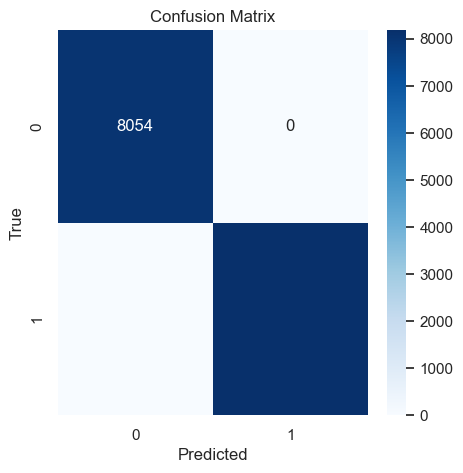

In [18]:
y_pred = model.predict(X_val)

print("Classification Report:")
print(classification_report(y_val_beats, y_pred))

# Confusion matrix
cm = confusion_matrix(y_val_beats, y_pred)
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# **Implementation With CNN**

In [19]:
# Feature extraction or Converting Beat to MFCC by increasing the MFCC count to 40
def beat_to_mfcc_image(beat, sr, n_mfcc=40, max_len=50):

    n_fft = min(2048, len(beat))

    mfcc = librosa.feature.mfcc(
        y=beat,
        sr=sr,
        n_mfcc=n_mfcc,
        n_fft=n_fft
    )

    # Normalize
    mfcc = (mfcc - np.min(mfcc)) / (np.max(mfcc) - np.min(mfcc) + 1e-6)

    # Pad or truncate to fixed length
    if mfcc.shape[1] < max_len:
        pad_width = max_len - mfcc.shape[1]
        mfcc = np.pad(mfcc, pad_width=((0,0),(0,pad_width)), mode='constant')
    else:
        mfcc = mfcc[:, :max_len]

    return mfcc

In [20]:
# Build Dataset for CNN
X_train_cnn = []
y_train_cnn = []

for i, (signal, sr) in enumerate(train_audio):

    beats = segment_beats(signal, sr)

    for beat in beats:

        mfcc_img = beat_to_mfcc_image(beat, sr)

        X_train_cnn.append(mfcc_img)
        y_train_cnn.append(y_train[i])


X_train_cnn = np.array(X_train_cnn)
X_train_cnn = X_train_cnn[..., np.newaxis]
y_train_cnn = np.array(y_train_cnn)

print(X_train_cnn.shape)


X_val_cnn = []
y_val_cnn = []

for i, (signal, sr) in enumerate(val_audio):

    beats = segment_beats(signal, sr)

    for beat in beats:

        mfcc_img = beat_to_mfcc_image(beat, sr)

        X_val_cnn.append(mfcc_img)
        y_val_cnn.append(y_val[i])


X_val_cnn = np.array(X_val_cnn)
X_val_cnn = X_val_cnn[..., np.newaxis]
y_val_cnn = np.array(y_val_cnn)

print(X_val_cnn.shape)

(188523, 40, 50, 1)
(16239, 40, 50, 1)


In [21]:
X_train_cnn.shape

(188523, 40, 50, 1)

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# The input_shape is explicitly set to (40, 50, 1) as X_train_cnn is expected to have shape (num_samples, 40, 50, 1).
# This bypasses the NameError if X_train_cnn is not yet defined in the kernel.
input_shape = (40, 50, 1)
# input_shape = X_train_cnn.shape[1:]

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
    MaxPooling2D((2,2)),
    Dropout(0.3),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Dropout(0.3),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(1e-3),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

/opt/anaconda3/envs/ml_tutorial_env/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 38, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 19, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 19, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 17, 22, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 11, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 11, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5632)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       360,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 379,393 (1.45 MB)

 Trainable params: 379,393 (1.45 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
history = model.fit(
    X_train_cnn, y_train_cnn,
    validation_data=(X_val_cnn, y_val_cnn),
    epochs=15,
    batch_size=32
)

Epoch 1/15
5892/5892 ━━━━━━━━━━━━━━━━━━━━ 81s 14ms/step - accuracy: 0.7677 - loss: 0.5172 - val_accuracy: 0.4960 - val_loss: 0.7789
Epoch 2/15
5892/5892 ━━━━━━━━━━━━━━━━━━━━ 84s 14ms/step - accuracy: 0.7678 - loss: 0.4819 - val_accuracy: 0.4960 - val_loss: 0.7888
Epoch 3/15
5892/5892 ━━━━━━━━━━━━━━━━━━━━ 91s 15ms/step - accuracy: 0.7678 - loss: 0.4752 - val_accuracy: 0.4960 - val_loss: 0.7011
Epoch 4/15
5892/5892 ━━━━━━━━━━━━━━━━━━━━ 85s 14ms/step - accuracy: 0.7678 - loss: 0.4698 - val_accuracy: 0.4960 - val_loss: 0.7674
Epoch 5/15
5892/5892 ━━━━━━━━━━━━━━━━━━━━ 86s 15ms/step - accuracy: 0.7678 - loss: 0.4670 - val_accuracy: 0.4960 - val_loss: 0.6794
Epoch 6/15
5892/5892 ━━━━━━━━━━━━━━━━━━━━ 83s 14ms/step - accuracy: 0.7678 - loss: 0.4648 - val_accuracy: 0.4960 - val_loss: 0.7058
Epoch 7/15
5892/5892 ━━━━━━━━━━━━━━━━━━━━ 81s 14ms/step - accuracy: 0.7678 - loss: 0.4624 - val_accuracy: 0.4960 - val_loss: 0.7252
Epoch 8/15
5892/5892 ━━━━━━━━━━━━━━━━━━━━ 81s 14ms/step - accuracy: 0.7678 -

508/508 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


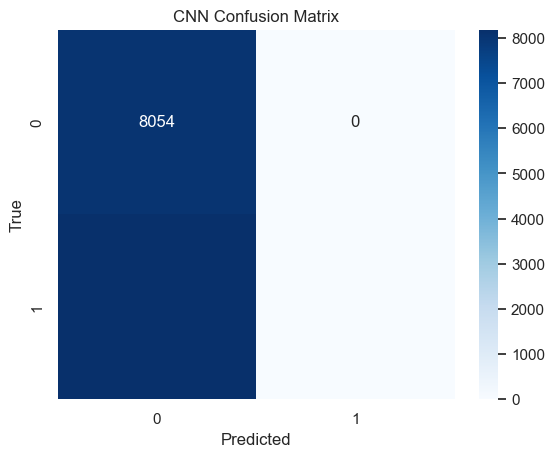

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_cnn = (model.predict(X_val_cnn) > 0.5).astype(int).flatten()
cm = confusion_matrix(y_val_cnn, y_pred_cnn)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("CNN Confusion Matrix")
plt.show()

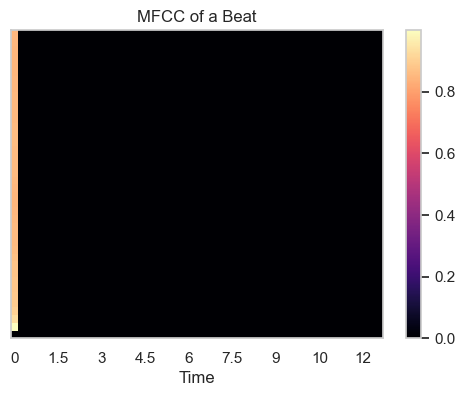

In [25]:
plt.figure(figsize=(6,4))
librosa.display.specshow(X_train_cnn[0,:,:,0], sr=sr, x_axis='time')
plt.colorbar()
plt.title("MFCC of a Beat")
plt.show()

# **Improve the CNN**

In [26]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train_cnn),
    y=y_train_cnn
)

class_weights = dict(enumerate(class_weights))

In [27]:
model.fit(
    X_train_cnn,
    y_train_cnn,
    validation_data=(X_val_cnn, y_val_cnn),
    epochs=20,
    batch_size=32,
    class_weight=class_weights
)

Epoch 1/20
5892/5892 ━━━━━━━━━━━━━━━━━━━━ 84s 14ms/step - accuracy: 0.6784 - loss: 0.5723 - val_accuracy: 0.6614 - val_loss: 0.6165
Epoch 2/20
5892/5892 ━━━━━━━━━━━━━━━━━━━━ 84s 14ms/step - accuracy: 0.6773 - loss: 0.5654 - val_accuracy: 0.6709 - val_loss: 0.6034
Epoch 3/20
5892/5892 ━━━━━━━━━━━━━━━━━━━━ 86s 15ms/step - accuracy: 0.6773 - loss: 0.5640 - val_accuracy: 0.6836 - val_loss: 0.5924
Epoch 4/20
5892/5892 ━━━━━━━━━━━━━━━━━━━━ 85s 14ms/step - accuracy: 0.6773 - loss: 0.5640 - val_accuracy: 0.6667 - val_loss: 0.6119
Epoch 5/20
5892/5892 ━━━━━━━━━━━━━━━━━━━━ 92s 16ms/step - accuracy: 0.6804 - loss: 0.5621 - val_accuracy: 0.6547 - val_loss: 0.6239
Epoch 6/20
5892/5892 ━━━━━━━━━━━━━━━━━━━━ 85s 14ms/step - accuracy: 0.6801 - loss: 0.5620 - val_accuracy: 0.6734 - val_loss: 0.6062
Epoch 7/20
5892/5892 ━━━━━━━━━━━━━━━━━━━━ 85s 14ms/step - accuracy: 0.6809 - loss: 0.5614 - val_accuracy: 0.6768 - val_loss: 0.6005
Epoch 8/20
5892/5892 ━━━━━━━━━━━━━━━━━━━━ 83s 14ms/step - accuracy: 0.6829 -

508/508 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
cm [[3695 4359]
 [1244 6941]]


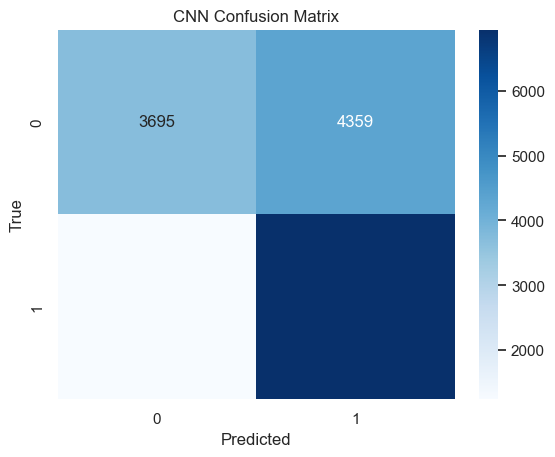

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_cnn = (model.predict(X_val_cnn) > 0.5).astype(int).flatten()
cm = confusion_matrix(y_val_cnn, y_pred_cnn)

print("cm", cm)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("CNN Confusion Matrix")
plt.show()

# **Improved CNN 2**

In [29]:
# Compute Class Weight
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train_cnn)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_cnn
)

class_weights = dict(zip(classes, weights))

print(class_weights)


{np.int64(0): np.float64(0.6512425643045163), np.int64(1): np.float64(2.152973824859531)}


In [30]:
# Improved CNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

input_shape = X_train_cnn.shape[1:]

model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/opt/anaconda3/envs/ml_tutorial_env/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 38, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 38, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 19, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 17, 22, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 17, 22, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 11, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 6, 9, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 6, 9, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 3, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       196,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 290,433 (1.11 MB)

 Trainable params: 289,985 (1.11 MB)

 Non-trainable params: 448 (1.75 KB)

In [31]:
# Early Stopping
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [32]:
# Train the model
history = model.fit(
    X_train_cnn,
    y_train_cnn,
    validation_data=(X_val_cnn, y_val_cnn),
    epochs=40,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/40
5892/5892 ━━━━━━━━━━━━━━━━━━━━ 155s 26ms/step - accuracy: 0.6778 - loss: 0.6013 - val_accuracy: 0.5040 - val_loss: 7.4211
Epoch 2/40
5892/5892 ━━━━━━━━━━━━━━━━━━━━ 144s 25ms/step - accuracy: 0.7199 - loss: 0.5212 - val_accuracy: 0.5042 - val_loss: 4.7348
Epoch 3/40
5892/5892 ━━━━━━━━━━━━━━━━━━━━ 145s 25ms/step - accuracy: 0.7228 - loss: 0.5023 - val_accuracy: 0.5389 - val_loss: 0.7950
Epoch 4/40
5892/5892 ━━━━━━━━━━━━━━━━━━━━ 147s 25ms/step - accuracy: 0.7182 - loss: 0.5066 - val_accuracy: 0.5040 - val_loss: 4.6826
Epoch 5/40
5892/5892 ━━━━━━━━━━━━━━━━━━━━ 136s 23ms/step - accuracy: 0.7258 - loss: 0.4864 - val_accuracy: 0.5040 - val_loss: 1.8641
Epoch 6/40
5892/5892 ━━━━━━━━━━━━━━━━━━━━ 138s 23ms/step - accuracy: 0.7279 - loss: 0.4815 - val_accuracy: 0.4960 - val_loss: 53.7153
Epoch 7/40
5892/5892 ━━━━━━━━━━━━━━━━━━━━ 135s 23ms/step - accuracy: 0.7315 - loss: 0.4754 - val_accuracy: 0.5654 - val_loss: 0.7039
Epoch 8/40
5892/5892 ━━━━━━━━━━━━━━━━━━━━ 136s 23ms/step - accuracy:

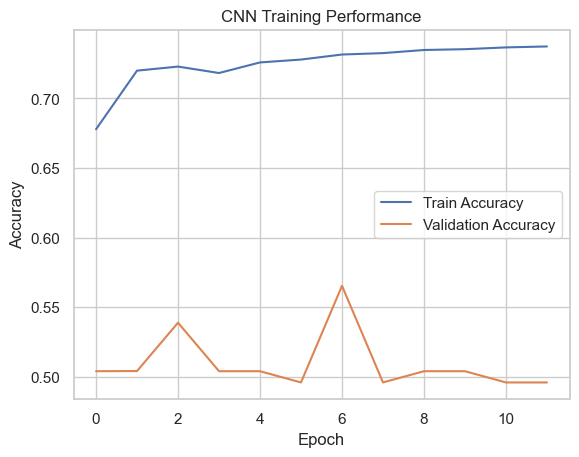

In [33]:
# Plot the Training Curves
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.legend()
plt.title("CNN Training Performance")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

508/508 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
[[1010 7044]
 [  14 8171]]


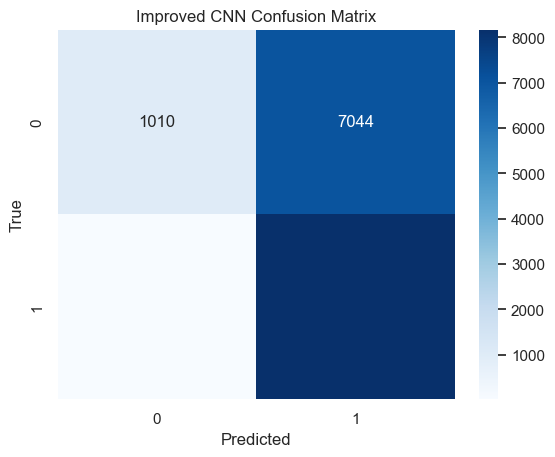

In [34]:
# Evalute the model
y_pred = (model.predict(X_val_cnn) > 0.5).astype(int).flatten()

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val_cnn, y_pred)
print(cm)

import seaborn as sns

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Improved CNN Confusion Matrix")
plt.show()

# **Final Improvement**

In [35]:
# Improved Feature Extraction
import librosa
import numpy as np

def beat_to_feature_map(beat, sr, max_len=50):

    n_fft = min(2048, len(beat))

    # MFCC
    mfcc = librosa.feature.mfcc(y=beat, sr=sr, n_mfcc=40, n_fft=n_fft)

    # Spectral centroid
    centroid = librosa.feature.spectral_centroid(y=beat, sr=sr, n_fft=n_fft)

    # Zero crossing rate
    zcr = librosa.feature.zero_crossing_rate(beat)

    # Chroma
    chroma = librosa.feature.chroma_stft(y=beat, sr=sr, n_fft=n_fft)

    # Stack features
    feature_map = np.vstack([mfcc, centroid, zcr, chroma])

    # Normalize
    feature_map = (feature_map - np.min(feature_map)) / (np.max(feature_map) - np.min(feature_map) + 1e-6)

    # Pad or truncate time dimension
    if feature_map.shape[1] < max_len:
        pad = max_len - feature_map.shape[1]
        feature_map = np.pad(feature_map, ((0,0),(0,pad)), mode='constant')
    else:
        feature_map = feature_map[:, :max_len]

    return feature_map

In [36]:
X_train_cnn = []
y_train_cnn = []

for i, (signal, sr) in enumerate(train_audio):

    beats = segment_beats(signal, sr)

    beats = beats[:20]   # limit to avoid huge dataset

    for beat in beats:

        feature_map = beat_to_feature_map(beat, sr)

        X_train_cnn.append(feature_map)
        y_train_cnn.append(y_train[i])

X_train_cnn = np.array(X_train_cnn)
X_train_cnn = X_train_cnn[..., np.newaxis]

y_train_cnn = np.array(y_train_cnn)

print(X_train_cnn.shape)

/opt/anaconda3/envs/ml_tutorial_env/lib/python3.13/site-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


(64597, 54, 50, 1)


In [37]:
# Fix the model architecture for new input shape
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

input_shape = X_train_cnn.shape[1:]  # (54, 50, 1)

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    
    Flatten(),
    
    Dense(256, activation='relu'),  # Increased to handle larger input
    Dropout(0.5),
    
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/opt/anaconda3/envs/ml_tutorial_env/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 52, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 52, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 24, 22, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 24, 22, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 12, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 10, 9, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 10, 9, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2560)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       655,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 749,441 (2.86 MB)

 Trainable params: 748,993 (2.86 MB)

 Non-trainable params: 448 (1.75 KB)

In [38]:
# Create validation dataset with new features
X_val_cnn = []
y_val_cnn = []

for i, (signal, sr) in enumerate(val_audio):
    beats = segment_beats(signal, sr)
    beats = beats[:20]   # limit to match training
    
    for beat in beats:
        feature_map = beat_to_feature_map(beat, sr)
        X_val_cnn.append(feature_map)
        y_val_cnn.append(y_val[i])

X_val_cnn = np.array(X_val_cnn)
X_val_cnn = X_val_cnn[..., np.newaxis]
y_val_cnn = np.array(y_val_cnn)

print(X_val_cnn.shape)


(5961, 54, 50, 1)


In [39]:
# Train the corrected model
history = model.fit(
    X_train_cnn,
    y_train_cnn,
    validation_data=(X_val_cnn, y_val_cnn),
    epochs=40,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/40
2019/2019 ━━━━━━━━━━━━━━━━━━━━ 76s 36ms/step - accuracy: 0.7637 - loss: 0.6731 - val_accuracy: 0.4986 - val_loss: 0.6945
Epoch 2/40
2019/2019 ━━━━━━━━━━━━━━━━━━━━ 78s 39ms/step - accuracy: 0.7915 - loss: 0.6624 - val_accuracy: 0.4986 - val_loss: 0.6965
Epoch 3/40
2019/2019 ━━━━━━━━━━━━━━━━━━━━ 70s 35ms/step - accuracy: 0.7950 - loss: 0.6618 - val_accuracy: 0.4986 - val_loss: 0.6966
Epoch 4/40
2019/2019 ━━━━━━━━━━━━━━━━━━━━ 67s 33ms/step - accuracy: 0.7950 - loss: 0.6618 - val_accuracy: 0.4986 - val_loss: 0.6967
Epoch 5/40
2019/2019 ━━━━━━━━━━━━━━━━━━━━ 64s 32ms/step - accuracy: 0.7950 - loss: 0.6618 - val_accuracy: 0.4986 - val_loss: 0.6969
Epoch 6/40
2019/2019 ━━━━━━━━━━━━━━━━━━━━ 66s 33ms/step - accuracy: 0.7950 - loss: 0.6618 - val_accuracy: 0.4986 - val_loss: 0.6965


187/187 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
[[2972    0]
 [2989    0]]


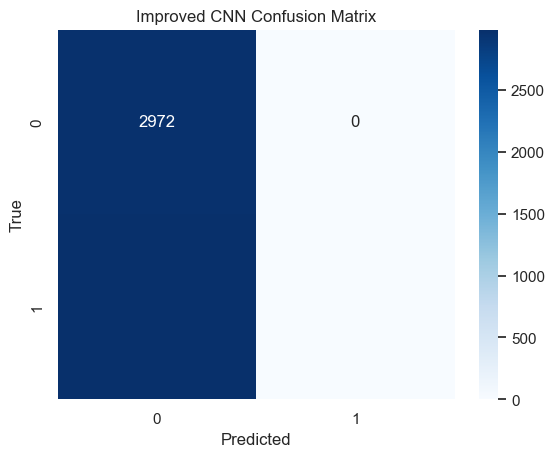

In [40]:
# Evalute the model
y_pred = (model.predict(X_val_cnn) > 0.5).astype(int).flatten()

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val_cnn, y_pred)
print(cm)

import seaborn as sns

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Improved CNN Confusion Matrix")
plt.show()